<a href="https://colab.research.google.com/github/Geethika1205/SML/blob/main/plantdisease_ug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (10).zip to archive (10).zip


In [2]:
import zipfile

zip_path = "/content/archive (10).zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    print(root, len(files))

/content/PlantDoc 2
/content/PlantDoc/test 0
/content/PlantDoc/test/grape_leaf 12
/content/PlantDoc/test/Tomato_leaf 8
/content/PlantDoc/test/Bell_pepper_leaf_spot 9
/content/PlantDoc/test/Tomato_leaf_mosaic_virus 10
/content/PlantDoc/test/Squash_Powdery_mildew_leaf 6
/content/PlantDoc/test/Apple_rust_leaf 10
/content/PlantDoc/test/Corn_Gray_leaf_spot 4
/content/PlantDoc/test/Cherry_leaf 10
/content/PlantDoc/test/Soyabean_leaf 8
/content/PlantDoc/test/Tomato_mold_leaf 6
/content/PlantDoc/test/Tomato_leaf_bacterial_spot 9
/content/PlantDoc/test/Raspberry_leaf 7
/content/PlantDoc/test/Tomato_Early_blight_leaf 9
/content/PlantDoc/test/Tomato_Septoria_leaf_spot 12
/content/PlantDoc/test/grape_leaf_black_rot 8
/content/PlantDoc/test/Corn_rust_leaf 10
/content/PlantDoc/test/Blueberry_leaf 11
/content/PlantDoc/test/Strawberry_leaf 8
/content/PlantDoc/test/Tomato_leaf_late_blight 10
/content/PlantDoc/test/Tomato_leaf_yellow_virus 15
/content/PlantDoc/test/Peach_leaf 9
/content/PlantDoc/test/Co

In [4]:
from PIL import Image
import os

folder = "/content/PlantDoc"
sample = None

for root, dirs, files in os.walk(folder):
    for f in files[:1]:
        sample = os.path.join(root, f)

img = Image.open(sample)
img.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="training"
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset="validation"
)

Found 2338 images belonging to 2 classes.
Found 584 images belonging to 2 classes.


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# Freeze early layers
for layer in base_model.layers:
    layer.trainable = False

# Attention block
def attention_block(x):
    attn = layers.Conv2D(1,1,activation='sigmoid')(x)
    return layers.multiply([x, attn])

x = base_model.output
x = attention_block(x)
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(base_model.input, output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9008 - loss: 0.3313 - val_accuracy: 0.9144 - val_loss: 0.2937
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 980ms/step - accuracy: 0.9136 - loss: 0.3065 - val_accuracy: 0.9144 - val_loss: 0.2932
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 983ms/step - accuracy: 0.9136 - loss: 0.2984 - val_accuracy: 0.9144 - val_loss: 0.2961
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 995ms/step - accuracy: 0.9136 - loss: 0.3003 - val_accuracy: 0.9144 - val_loss: 0.3045
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 997ms/step - accuracy: 0.9136 - loss: 0.2996 - val_accuracy: 0.9144 - val_loss: 0.3002
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 991ms/step - accuracy: 0.9136 - loss: 0.3009 - val_accuracy: 0.9144 - val_loss: 0.2951
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 72s 984ms/step - accuracy: 0.9136 - loss: 0.3010 - val_accuracy: 0.9144 - val_loss: 0.2929
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 72s 983ms/step - accuracy: 0.9136 - loss: 0.2989 - val_accura

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.9197 - loss: 0.2839

74/74 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9136 - loss: 0.2968 - val_accuracy: 0.9144 - val_loss: 0.3097
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 989ms/step - accuracy: 0.9136 - loss: 0.3020 - val_accuracy: 0.9144 - val_loss: 0.2921
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 987ms/step - accuracy: 0.9136 - loss: 0.2982 - val_accuracy: 0.9144 - val_loss: 0.2965
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 72s 974ms/step - accuracy: 0.9136 - loss: 0.3028 - val_accuracy: 0.9144 - val_loss: 0.2968
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 985ms/step - accuracy: 0.9136 - loss: 0.2985 - val_accuracy: 0.9144 - val_loss: 0.2973
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 989ms/step - accuracy: 0.9136 - loss: 0.2965 - val_accuracy: 0.9144 - val_loss: 0.2956
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 73s 991ms/step - accuracy: 0.9136 - loss: 0.3010 - val_accuracy: 0.9144 - val_loss: 0.2935


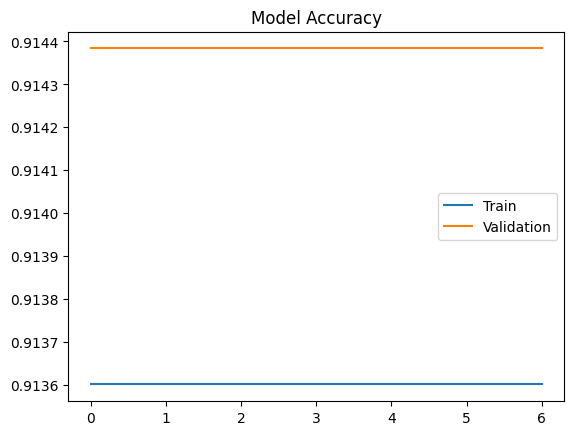

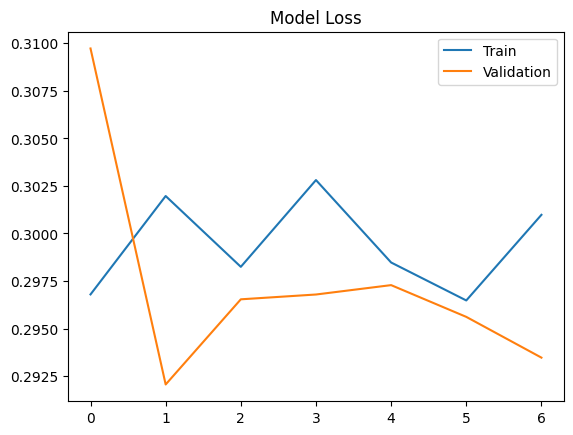

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [12]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 824ms/step - accuracy: 0.9144 - loss: 0.2921
Validation Accuracy: 0.914383590221405


In [13]:
from tensorflow.keras import layers, models

def unet_model():
    inputs = layers.Input((224,224,3))

    # Encoder
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)

    # Decoder
    u1 = layers.UpSampling2D()(c2)
    concat = layers.Concatenate()([u1,c1])

    outputs = layers.Conv2D(1,1,activation='sigmoid')(concat)

    return models.Model(inputs, outputs)

seg_model = unet_model()

seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

seg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 224, 224,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │         97 │ concatenate[0][0] │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,489 (76.13 KB)

 Trainable params: 19,489 (76.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import numpy as np

def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0.5)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [15]:
import cv2
import numpy as np
import os

def generate_mask(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # detect brown/yellow diseased areas
    lower = np.array([10,40,40])
    upper = np.array([35,255,255])

    mask = cv2.inRange(hsv, lower, upper)
    return mask

In [16]:
from google.colab import files
uploaded = files.upload()

Saving ChatGPT Image Mar 16, 2026, 11_02_50 PM.png to ChatGPT Image Mar 16, 2026, 11_02_50 PM.png


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

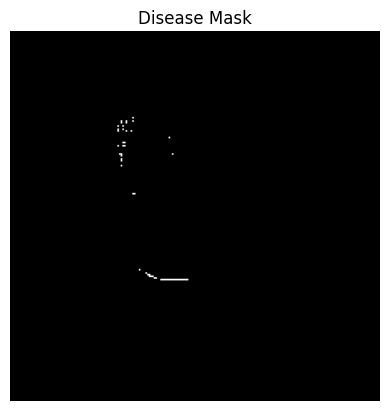

In [17]:
import matplotlib.pyplot as plt

sample_img = "/content/ChatGPT Image Mar 16, 2026, 11_02_50 PM.png"  # change path
mask = generate_mask(sample_img)

plt.imshow(mask, cmap='gray')
plt.title("Disease Mask")
plt.axis("off")

In [18]:
seg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
def disease_percentage(mask):
    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    return (disease_pixels / total_pixels) * 100

In [20]:
import numpy as np
import cv2
import os

image_paths = []
masks = []

dataset_path = "/content/PlantDoc"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg','.png','.jpeg','.webp')):
            path = os.path.join(root,file)
            img = cv2.imread(path)
            img = cv2.resize(img,(224,224))

            hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
            lower = np.array([10,40,40])
            upper = np.array([35,255,255])
            mask = cv2.inRange(hsv,lower,upper)

            image_paths.append(img/255.0)
            masks.append(mask/255.0)

X = np.array(image_paths)
Y = np.array(masks)
Y = Y.reshape(-1,224,224,1)

In [ ]:
seg_model.fit(
    X, Y,
    batch_size=16,
    epochs=10,
    validation_split=0.2
)